In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report as cr
from sklearn.preprocessing import StandardScaler
data = pd.read_csv('categ.csv')

C:\Users\admin\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
data.head(5)

,Unnamed: 0,size,material,color,sleeves,demand
0,0,S,nylon,white,long,medium
1,1,XL,polyester,cream,short,high
2,2,S,silk,blue,short,medium
3,3,M,cotton,black,short,medium
4,4,XL,polyester,orange,long,medium


In [19]:
data['demand'].value_counts()

demand
medium    4368
high      4329
low       1303
Name: count, dtype: int64

In [18]:
data['sleeves'].value_counts()

sleeves
long     5044
short    4956
Name: count, dtype: int64

In [17]:
data['color'].value_counts()

color
white     1646
black     1538
navy      1132
cream     1123
blue      1000
red        998
yellow     701
violet     662
orange     659
green      541
Name: count, dtype: int64

In [13]:
data['material'].value_counts()

material
polyester    2840
nylon        2800
cotton       2154
linen        1633
silk          573
Name: count, dtype: int64

In [9]:
data['size'].value_counts()

size
L      2231
XL     1740
M      1727
XXL    1290
S      1284
XS      883
3XL     845
Name: count, dtype: int64

In [6]:
data.shape

(10000, 6)

In [7]:
data.describe()

,Unnamed: 0
count,10000.00000
mean,4999.50000
std,2886.89568
min,0.00000
25%,2499.75000
50%,4999.50000
75%,7499.25000
max,9999.00000


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  10000 non-null  int64 
 1   size        10000 non-null  object
 2   material    10000 non-null  object
 3   color       10000 non-null  object
 4   sleeves     10000 non-null  object
 5   demand      10000 non-null  object
dtypes: int64(1), object(5)
memory usage: 468.9+ KB


In [11]:
#convert caltegorical values into numeric
data['size'] = pd.factorize(data['size'])[0]

In [12]:
data['size'].value_counts()

size
5    2231
1    1740
2    1727
4    1290
0    1284
3     883
6     845
Name: count, dtype: int64

In [15]:
data['material'] = pd.factorize(data['material'])[0]

In [16]:
data['material'].value_counts()

material
1    2840
0    2800
3    2154
4    1633
2     573
Name: count, dtype: int64

In [20]:
data['color'] = pd.factorize(data['color'])[0]
data['sleeves'] = pd.factorize(data['sleeves'])[0]
data['demand'] = pd.factorize(data['demand'])[0]

In [22]:
print(data['color'].value_counts())
print(data['sleeves'].value_counts())
print(data['demand'].value_counts())

color
0    1646
3    1538
9    1132
1    1123
2    1000
7     998
6     701
8     662
4     659
5     541
Name: count, dtype: int64
sleeves
0    5044
1    4956
Name: count, dtype: int64
demand
0    4368
1    4329
2    1303
Name: count, dtype: int64


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

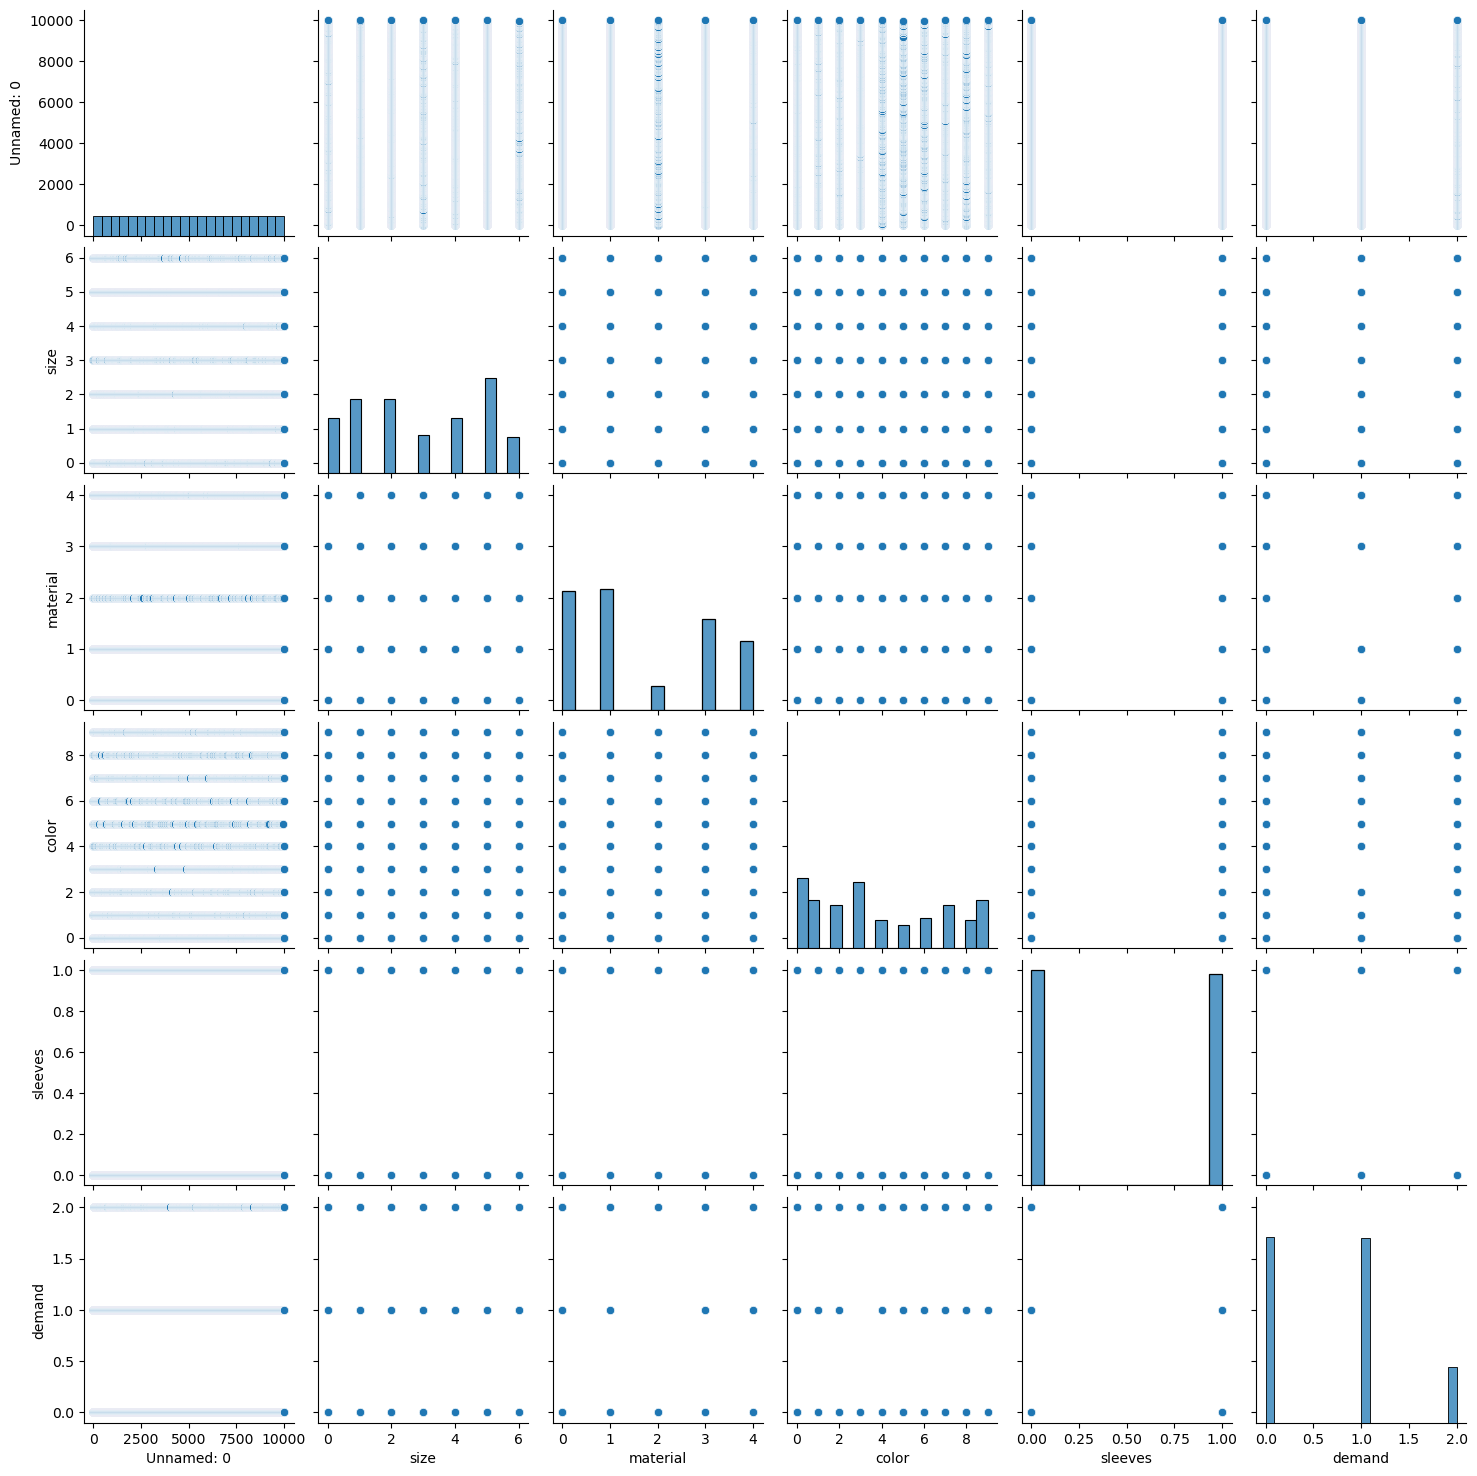

In [23]:
sns.pairplot(data)

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


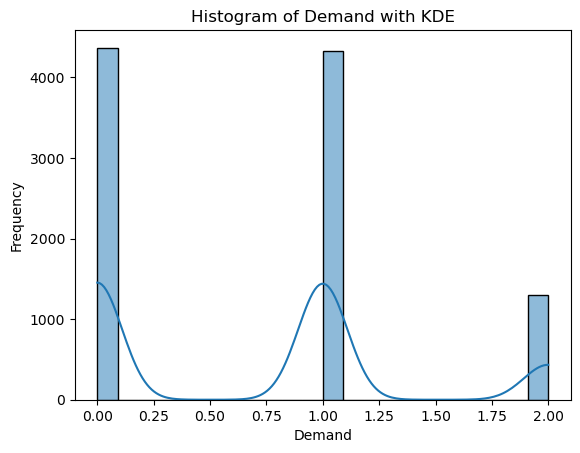

In [28]:
sns.histplot(data['demand'], kde=True)
plt.xlabel('Demand')
plt.ylabel('Frequency')
plt.title('Histogram of Demand with KDE')
plt.show()

In [33]:
from sklearn.naive_bayes import CategoricalNB
x = data.drop('demand', axis = 1)
y = data['demand']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 20)

In [34]:
model = CategoricalNB().fit(x_train, y_train)
y_pred = model.predict(x_test)

In [36]:
print(cr(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.86      0.82      1321
           1       0.85      0.89      0.87      1250
           2       0.80      0.45      0.58       429

    accuracy                           0.81      3000
   macro avg       0.81      0.73      0.76      3000
weighted avg       0.81      0.81      0.81      3000



In [38]:
from sklearn.metrics import confusion_matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)


Confusion Matrix:
[[1134  139   48]
 [ 138 1112    0]
 [ 180   54  195]]


<Axes: >

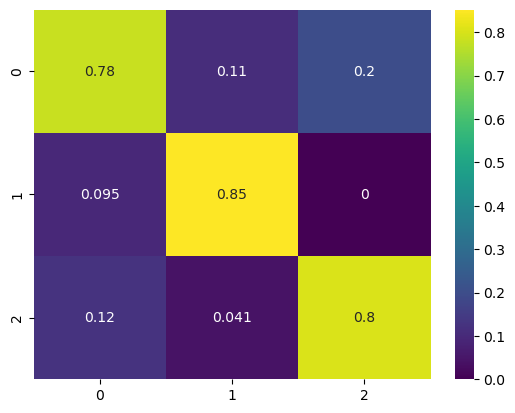

In [39]:
sns.heatmap(conf_matrix/sum(conf_matrix), annot = True, cmap = 'viridis')

In [42]:
from sklearn.metrics import roc_curve, roc_auc_score
y_pred_proba = model.predict_proba(x_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_value = roc_auc_score(y_test, y_pred_proba)

# Plot ROC curve
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_value:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend()
plt.show()

ValueError: multiclass format is not supported

In [44]:
from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_bin.shape[1]

# Compute ROC curve and ROC AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and AUC
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_pred_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curve for each class
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

# Plot micro-average ROC curve
plt.plot(fpr["micro"], tpr["micro"], label=f'Micro-average (AUC = {roc_auc["micro"]:.2f})', linestyle='--', color='k')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve for Multiclass Classification')
plt.legend()
plt.show()

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [45]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Compute ROC curve and AUC for binary classification
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve for Binary Classification')
plt.legend()
plt.show()

ValueError: multiclass format is not supported

In [46]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Binarize the target labels for multiclass classification
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_bin.shape[1]

# Ensure y_pred_proba is 2D (n_samples, n_classes)
if y_pred_proba.ndim == 1:
    y_pred_proba = np.vstack([1 - y_pred_proba, y_pred_proba]).T  # For binary case

# Compute ROC curve and ROC AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and AUC
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_pred_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curve for each class
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

# Plot micro-average ROC curve
plt.plot(fpr["micro"], tpr["micro"], label=f'Micro-average (AUC = {roc_auc["micro"]:.2f})', linestyle='--', color='k')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve for Multiclass Classification')
plt.legend()
plt.show()

IndexError: index 2 is out of bounds for axis 1 with size 2

In [47]:
print(y_pred_proba.shape)

(3000, 2)


In [48]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Binarize the target labels for multiclass classification
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_bin.shape[1]  # Number of classes

# Compute ROC curve and ROC AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and AUC
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_pred_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curve for each class
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

# Plot micro-average ROC curve
plt.plot(fpr["micro"], tpr["micro"], label=f'Micro-average (AUC = {roc_auc["micro"]:.2f})', linestyle='--', color='k')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve for Multiclass Classification')
plt.legend()
plt.show()

IndexError: index 2 is out of bounds for axis 1 with size 2